# Classical ML 

Four tasks, three practical classifiers, and `GridSearchCV` (5-fold) on train only. The notebook now reads a unified feature table and defines each task from the experiment-specific split columns created in `02_windowing.ipynb`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
FEAT = ROOT / 'features'
RES = ROOT / 'results'
FIG = ROOT / 'figures'
RES.mkdir(exist_ok=True)

OWNER = 'Pedro'
META_COLS = {
    'participant', 'context', 'session', 'window_idx', 'label_person', 'label_context',
    'split_owner_person', 'split_context', 'use_owner_person', 'use_context',
    'participant_id', 'label_owner', 'label_context_bin',
}

FEATURE_SET_FILES = {
    'Engineered': FEAT / 'feature_matrix_all.csv',
    'PCA': FEAT / 'feature_matrix_all_pca.csv',
    'Reduced engineered': FEAT / 'feature_matrix_all_reduced.csv',
}

feature_sets = {}
feature_cols_map = {}
for feature_set_name, path in FEATURE_SET_FILES.items():
    if path.exists():
        df = pd.read_csv(path)
        feature_sets[feature_set_name] = df
        feature_cols_map[feature_set_name] = [c for c in df.columns if c not in META_COLS]

print('Available feature sets:')
for feature_set_name, cols in feature_cols_map.items():
    print(f'  {feature_set_name}: {len(cols)} columns')

MODELS = {
    'Logistic Regression': (
        LogisticRegression(max_iter=5000, random_state=42),
        {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [100], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 5]}
    ),
    'SVM (RBF)': (
        SVC(probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'class_weight': [None, 'balanced']}
    ),
}

Available feature sets:
  Engineered: 101 columns
  PCA: 38 columns
  Reduced engineered: 90 columns


In [2]:
def eval_binary(y_true, y_pred, y_prob):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
    }
    out['roc_auc'] = roc_auc_score(y_true, y_prob[:, 1]) if len(np.unique(y_true)) == 2 else np.nan
    return out


def get_task_data(df, task_id):
    if task_id == 1:
        tr = df[(df['context'] == 'normal') & (df['split_owner_person'] == 'train')]
        te = df[(df['context'] == 'normal') & (df['split_owner_person'] == 'test')]
        return tr, te, tr['label_owner'], te['label_owner'], 'binary'
    if task_id == 2:
        tr = df[(df['context'] == 'normal') & (df['split_owner_person'] == 'train')]
        te = df[(df['context'] == 'normal') & (df['split_owner_person'] == 'test')]
        return tr, te, tr['label_person'], te['label_person'], 'multiclass'
    if task_id == 3:
        tr = df[df['split_context'] == 'train']
        te = df[df['split_context'] == 'test']
        return tr, te, tr['label_context_bin'], te['label_context_bin'], 'binary'
    raise ValueError(task_id)


TASKS = [(1, 'Owner authentication'), (2, 'Person identification'), (3, 'Context classification')]
results = []
best_models = {}
best_per_task = {}

for feature_set_name, df in feature_sets.items():
    feat_cols = feature_cols_map[feature_set_name]
    print(f'\n### Feature set: {feature_set_name} ({len(feat_cols)} columns) ###')

    for task_id, task_name in TASKS:
        tr, te, y_tr, y_te, task_type = get_task_data(df, task_id)
        print(f'\n=== {task_name} ===')
        print(f'Train windows: {len(tr)}, Test windows: {len(te)}')
        print('Train balance:\n', y_tr.value_counts())
        print('Test balance:\n', y_te.value_counts())

        X_tr, X_te = tr[feat_cols], te[feat_cols]
        scaler = StandardScaler()
        best_score, best_name, best_clf, best_pred, best_prob = -1, None, None, None, None
        best_scaler = None

        for name, (est, grid) in MODELS.items():
            scale = name in ('Logistic Regression', 'SVM (RBF)')
            Xtr = scaler.fit_transform(X_tr) if scale else X_tr.values
            Xte = scaler.transform(X_te) if scale else X_te.values
            gs = GridSearchCV(est, grid, cv=5, scoring='accuracy', n_jobs=-1)
            gs.fit(Xtr, y_tr)
            pred = gs.predict(Xte)
            prob = gs.predict_proba(Xte)
            metrics = eval_binary(y_te, pred, prob) if task_type == 'binary' else {
                'accuracy': accuracy_score(y_te, pred),
                'macro_f1': f1_score(y_te, pred, average='macro', zero_division=0),
            }
            metrics.update({
                'task': task_name,
                'model': name,
                'feature_set': feature_set_name,
                'n_features': len(feat_cols),
                'best_params': str(gs.best_params_),
            })
            results.append(metrics)
            print(f"  {name}: acc={metrics['accuracy']:.3f}")
            if metrics['accuracy'] > best_score:
                best_score, best_name = metrics['accuracy'], name
                best_clf, best_pred, best_prob = gs.best_estimator_, pred, prob
                best_scaler = scaler if scale else None

        best_models[(feature_set_name, task_id)] = {
            'model_name': best_name,
            'clf': best_clf,
            'scaler': best_scaler,
            'train_df': tr,
            'test_df': te,
            'y_train': y_tr,
            'y_test': y_te,
            'pred': best_pred,
            'prob': best_prob,
            'feat_cols': feat_cols,
            'feature_set': feature_set_name,
            'accuracy': best_score,
        }
        print(f'  >> Best: {best_name} ({best_score:.3f})')

for task_id, task_name in TASKS:
    ranked = sorted(
        [best_models[(feature_set_name, task_id)] for feature_set_name in feature_sets],
        key=lambda item: item['accuracy'],
        reverse=True,
    )
    best_per_task[task_id] = ranked[0]

for feature_set_name, df in feature_sets.items():
    t1 = best_models[(feature_set_name, 1)]
    te_normal = t1['test_df']
    te_crowded = df[(df['context'] == 'crowded') & (df['split_context'] == 'test')]

    print(f'\n=== Cross-context robustness | {feature_set_name} ===')
    for subset_name, te_sub in [('normal_test', te_normal), ('crowded_test', te_crowded)]:
        Xte = t1['scaler'].transform(te_sub[t1['feat_cols']]) if t1['scaler'] else te_sub[t1['feat_cols']].values
        pred = t1['clf'].predict(Xte)
        prob = t1['clf'].predict_proba(Xte)
        m = eval_binary(te_sub['label_owner'], pred, prob)
        m.update({
            'task': 'Cross-context robustness',
            'model': t1['model_name'],
            'feature_set': feature_set_name,
            'n_features': len(t1['feat_cols']),
            'subset': subset_name,
            'best_params': 'from task 1',
        })
        results.append(m)
        print(f"  {subset_name}: n={len(te_sub)} acc={m['accuracy']:.3f} f1={m['f1']:.3f}")


### Feature set: Engineered (101 columns) ###

=== Owner authentication ===
Train windows: 1790, Test windows: 895
Train balance:
 label_owner
0    1432
1     358
Name: count, dtype: int64
Test balance:
 label_owner
0    716
1    179
Name: count, dtype: int64


  Logistic Regression: acc=0.997
  Random Forest: acc=1.000
  SVM (RBF): acc=0.991
  >> Best: Random Forest (1.000)

=== Person identification ===
Train windows: 1790, Test windows: 895
Train balance:
 label_person
Asena     358
Darius    358
Jun       358
Oana      358
Pedro     358
Name: count, dtype: int64
Test balance:
 label_person
Asena     179
Darius    179
Jun       179
Oana      179
Pedro     179
Name: count, dtype: int64
  Logistic Regression: acc=0.998
  Random Forest: acc=0.993
  SVM (RBF): acc=0.999
  >> Best: SVM (RBF) (0.999)

=== Context classification ===
Train windows: 1782, Test windows: 1786
Train balance:
 label_context_bin
0    895
1    887
Name: count, dtype: int64
Test balance:
 label_context_bin
0    895
1    891
Name: count, dtype: int64
  Logistic Regression: acc=0.787
  Random Forest: acc=0.809
  SVM (RBF): acc=0.833
  >> Best: SVM (RBF) (0.833)

### Feature set: PCA (38 columns) ###

=== Owner authentication ===
Train windows: 1790, Test windows: 895
Train 

In [3]:
res_df = pd.DataFrame(results)
res_df.to_csv(RES / 'classical_ml_results.csv', index=False)

print('\nBest representation/model per task:')
for task_id, task_name in TASKS:
    best = best_per_task[task_id]
    print(
        f"  {task_name}: {best['model_name']} on {best['feature_set']} "
        f"(acc={best['accuracy']:.3f}, n_features={len(best['feat_cols'])})"
    )

cross_best = res_df[(res_df['task'] == 'Cross-context robustness') & (res_df['subset'] == 'crowded_test')]
if not cross_best.empty:
    cross_best = cross_best.loc[cross_best['accuracy'].idxmax()]
    print(
        f"  Cross-context robustness: {cross_best['model']} on {cross_best['feature_set']} "
        f"(crowded acc={cross_best['accuracy']:.3f})"
    )

res_df


Best representation/model per task:
  Owner authentication: Random Forest on Engineered (acc=1.000, n_features=101)
  Person identification: SVM (RBF) on Engineered (acc=0.999, n_features=101)
  Context classification: SVM (RBF) on Engineered (acc=0.833, n_features=101)
  Cross-context robustness: Logistic Regression on PCA (crowded acc=0.930)


,accuracy,f1,precision,recall,roc_auc,task,model,feature_set,n_features,best_params,macro_f1,subset
0,0.996648,0.991597,0.994382,0.988827,0.999984,Owner authentication,Logistic Regression,Engineered,101,"{'C': 0.1, 'class_weight': None}",NaN,NaN
1,1.000000,1.000000,1.000000,1.000000,1.000000,Owner authentication,Random Forest,Engineered,101,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",NaN,NaN
2,0.991061,0.977143,1.000000,0.955307,1.000000,Owner authentication,SVM (RBF),Engineered,101,"{'C': 10, 'class_weight': None, 'gamma': 'auto'}",NaN,NaN
3,0.997765,NaN,NaN,NaN,NaN,Person identification,Logistic Regression,Engineered,101,"{'C': 1, 'class_weight': None}",0.997765,NaN
4,0.993296,NaN,NaN,NaN,NaN,Person identification,Random Forest,Engineered,101,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.993295,NaN
5,0.998883,NaN,NaN,NaN,NaN,Person identification,SVM (RBF),Engineered,101,"{'C': 1, 'class_weight': None, 'gamma': 'scale'}",0.998883,NaN
6,0.787234,0.794150,0.767539,0.822671,0.871004,Context classification,Logistic Regression,Engineered,101,"{'C': 0.1, 'class_weight': 'balanced'}",NaN,NaN
7,0.808511,0.831361,0.741425,0.946128,0.888644,Context classification,Random Forest,Engineered,101,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",NaN,NaN
8,0.833147,0.840129,0.804728,0.878788,0.876247,Context classification,SVM (RBF),Engineered,101,"{'C': 1, 'class_weight': None, 'gamma': 'scale'}",NaN,NaN
9,0.997765,0.994444,0.988950,1.000000,1.000000,Owner authentication,Logistic Regression,PCA,38,"{'C': 0.1, 'class_weight': None}",NaN,NaN


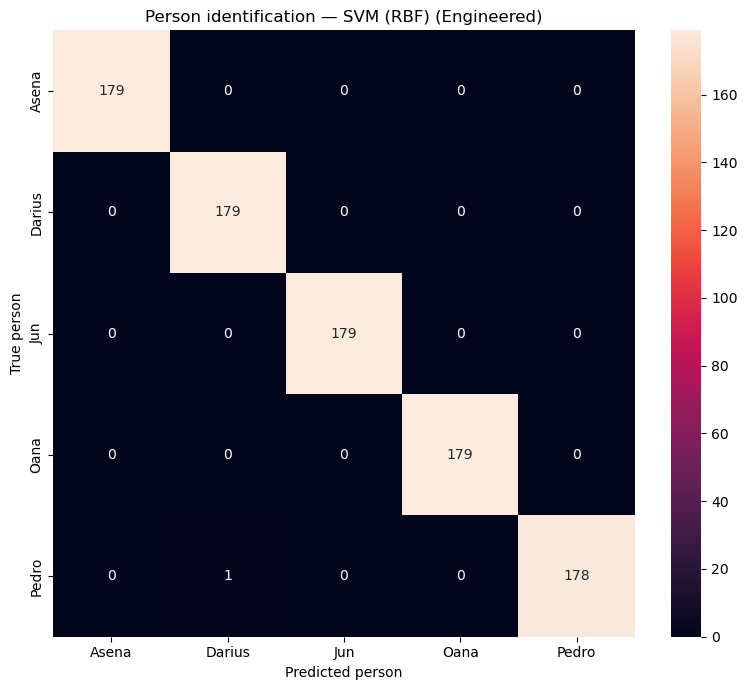

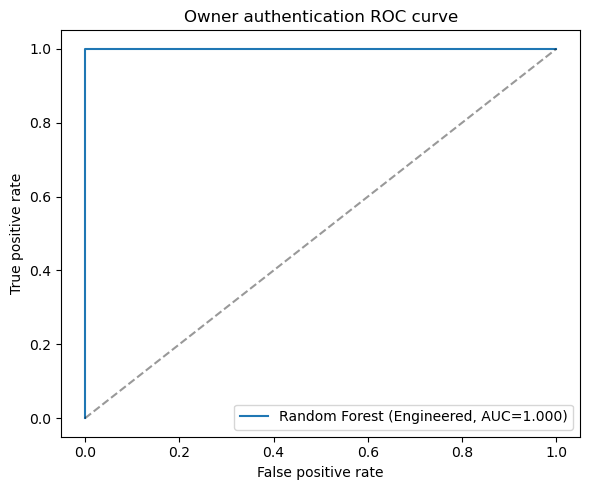

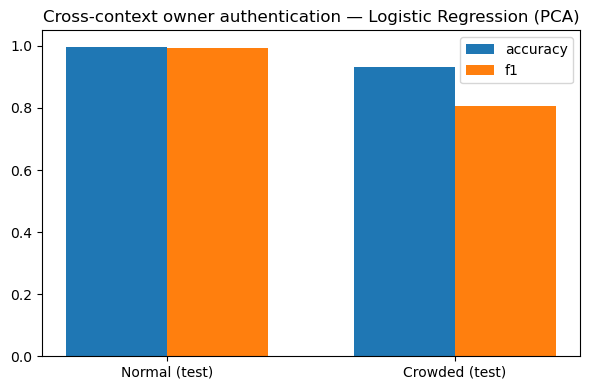


Best model per task:
  Owner authentication: Random Forest on Engineered (acc=1.000, n_features=101)
  Person identification: SVM (RBF) on Engineered (acc=0.999, n_features=101)
  Context classification: SVM (RBF) on Engineered (acc=0.833, n_features=101)


In [4]:
# Figures using the best-performing representation per task
best_person = best_per_task[2]
te2 = best_person['test_df']
y_te2 = best_person['y_test']
pred2 = best_person['pred']
labels2 = sorted(y_te2.unique())
cm = confusion_matrix(y_te2, pred2, labels=labels2)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels2, yticklabels=labels2, ax=ax)
ax.set_xlabel('Predicted person')
ax.set_ylabel('True person')
ax.set_title(f"Person identification — {best_person['model_name']} ({best_person['feature_set']})")
fig.tight_layout()
fig.savefig(FIG / 'fig12_confusion_matrix_person_id.png', dpi=150)
plt.show()

best_owner = best_per_task[1]
y_te1 = best_owner['y_test']
prob1 = best_owner['prob']
fpr, tpr, _ = roc_curve(y_te1, prob1[:, 1])
auc = roc_auc_score(y_te1, prob1[:, 1])
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{best_owner['model_name']} ({best_owner['feature_set']}, AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Owner authentication ROC curve')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig13_roc_owner_auth.png', dpi=150)
plt.show()

cross_rows = res_df[res_df['task'] == 'Cross-context robustness']
cross_choice = cross_rows[cross_rows['subset'] == 'crowded_test'].sort_values('accuracy', ascending=False).iloc[0]
t4 = cross_rows[cross_rows['feature_set'] == cross_choice['feature_set']]
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
for i, metric in enumerate(['accuracy', 'f1']):
    vals = [t4.loc[t4['subset'] == s, metric].iloc[0] for s in ['normal_test', 'crowded_test']]
    ax.bar(x + i * 0.35, vals, 0.35, label=metric)
ax.set_xticks(x + 0.175)
ax.set_xticklabels(['Normal (test)', 'Crowded (test)'])
ax.set_ylim(0, 1.05)
ax.set_title(f"Cross-context owner authentication — {cross_choice['model']} ({cross_choice['feature_set']})")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig14_cross_context_normal_vs_crowded.png', dpi=150)
plt.show()

print('\nBest model per task:')
for task_id, task_name in TASKS:
    best = best_per_task[task_id]
    print(
        f"  {task_name}: {best['model_name']} on {best['feature_set']} "
        f"(acc={best['accuracy']:.3f}, n_features={len(best['feat_cols'])})"
    )

In [ ]:
# Report-ready summary tables

task_best_rows = []
for task_id, task_name in TASKS:
    best = best_per_task[task_id]
    task_best_rows.append({
        'task': task_name,
        'subset': '',
        'feature_set': best['feature_set'],
        'model': best['model_name'],
        'n_features': len(best['feat_cols']),
        'accuracy': best['accuracy'],
        'f1': np.nan,
        'macro_f1': np.nan,
        'precision': np.nan,
        'recall': np.nan,
        'roc_auc': np.nan,
    })

report_table = pd.DataFrame(task_best_rows)
for idx, row in report_table.iterrows():
    match = res_df[(res_df['task'] == row['task']) & (res_df['feature_set'] == row['feature_set']) & (res_df['model'] == row['model'])]
    if row['task'] == 'Owner authentication':
        report_table.loc[idx, ['f1', 'precision', 'recall', 'roc_auc']] = match[['f1', 'precision', 'recall', 'roc_auc']].iloc[0].values
    elif row['task'] == 'Person identification':
        report_table.loc[idx, ['macro_f1']] = match[['macro_f1']].iloc[0].values
    elif row['task'] == 'Context classification':
        report_table.loc[idx, ['f1', 'precision', 'recall', 'roc_auc']] = match[['f1', 'precision', 'recall', 'roc_auc']].iloc[0].values

cross_report = res_df[res_df['task'] == 'Cross-context robustness'].copy()
if not cross_report.empty:
    crowded_best = cross_report[cross_report['subset'] == 'crowded_test'].sort_values('accuracy', ascending=False).iloc[0]
    cross_feature_set = crowded_best['feature_set']
    cross_rows = cross_report[cross_report['feature_set'] == cross_feature_set].copy()
    cross_rows = cross_rows[['task', 'subset', 'feature_set', 'model', 'n_features', 'accuracy', 'f1', 'precision', 'recall', 'roc_auc']]
    cross_rows['macro_f1'] = np.nan
    report_table = pd.concat([report_table, cross_rows[report_table.columns]], ignore_index=True)

report_table = report_table[['task', 'subset', 'feature_set', 'model', 'n_features', 'accuracy', 'f1', 'macro_f1', 'precision', 'recall', 'roc_auc']]
report_table.to_csv(RES / 'classical_ml_report_table.csv', index=False)

print('\nReport-ready classical ML summary:')
display(report_table.round(4))
print('Saved:', RES / 'classical_ml_report_table.csv')